# DSW 2023: Churn Prediction for High-Value Customers with Active Learning (CatBoost)

EDA, preprocessing, and a comparison of CatBoost with a plain baseline, pool-based active learning, SMOTE, ADASYN, random undersampling and NearMiss on the high-CLTV customer segment.

In [1]:
import numpy as np 
from IPython.display import Image 
import pandas as pd 
import seaborn as sns 
import plotly.express as px
from plotly.offline import init_notebook_mode, iplot
import matplotlib.pyplot as pl
from sklearn.preprocessing import LabelEncoder
import imblearn
from collections import Counter
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, f1_score,recall_score, precision_score
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve, auc
from xgboost import XGBClassifier
import matplotlib
import os

DATA_DIR = "../data"
DATA_PATH = os.path.join(DATA_DIR, "telco_customer_churn_adapted_v2.xlsx")

In [2]:
data = pd.read_excel(DATA_PATH)

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Customer ID                   7043 non-null   int64  
 1   Tenure Months                 7043 non-null   int64  
 2   Location                      7043 non-null   object 
 3   Device Class                  7043 non-null   object 
 4   Games Product                 7043 non-null   object 
 5   Music Product                 7043 non-null   object 
 6   Education Product             7043 non-null   object 
 7   Call Center                   7043 non-null   object 
 8   Video Product                 7043 non-null   object 
 9   Use MyApp                     7043 non-null   object 
 10  Payment Method                7043 non-null   object 
 11  Monthly Purchase (Thou. IDR)  7043 non-null   float64
 12  Churn Label                   7043 non-null   object 
 13  Lon

In [4]:
def preprocessing(df):
    df = df.copy()
    df.loc[df["Games Product"] != "No internet service", "internet_service"] = 1
    df["internet_service"].fillna(0, inplace=True)
    df["Location"] = df["Location"].map({"Jakarta": 1, "Bandung": 0})
    df["Device Class"] = df["Device Class"].map({"High End": 2, "Mid End": 1, "Low End": 0})
    df["Games Product"] = df["Games Product"].map({"Yes": 1, "No": 0, "No internet service": 0})
    df["Music Product"] = df["Music Product"].map({"Yes": 1, "No": 0, "No internet service": 0})
    df["Education Product"] = df["Education Product"].map({"Yes": 1, "No": 0, "No internet service": 0})
    df["Call Center"] = df["Call Center"].map({"Yes": 1, "No": 0})
    df["Video Product"] = df["Video Product"].map({"Yes": 1, "No": 0, "No internet service": 0})
    df["Use MyApp"] = df["Use MyApp"].map({"Yes": 1, "No": 0, "No internet service": 0})
    df["Churn Label"] = df["Churn Label"].map({"Yes": 1, "No": 0})
    df = pd.get_dummies(df, columns=["Payment Method"], prefix="pm")
    return df

data = preprocessing(data)

In [5]:
data['CLTV (Predicted Thou. IDR)'].describe()

count    7043.000000
mean     5720.384481
std      1537.974298
min      2603.900000
25%      4509.700000
50%      5885.100000
75%      6994.650000
max      8450.000000
Name: CLTV (Predicted Thou. IDR), dtype: float64

In [6]:
data = data[data['CLTV (Predicted Thou. IDR)'] > 7000]

In [7]:
# Compute the correlation matrix
corr_matrix = data.corr()

# Select columns where the correlation with 'Churn' is greater than 0.1
correlation_threshold = 0.3
churn_correlation = corr_matrix['Churn Label']
selected_features = churn_correlation[churn_correlation.abs() > correlation_threshold].index

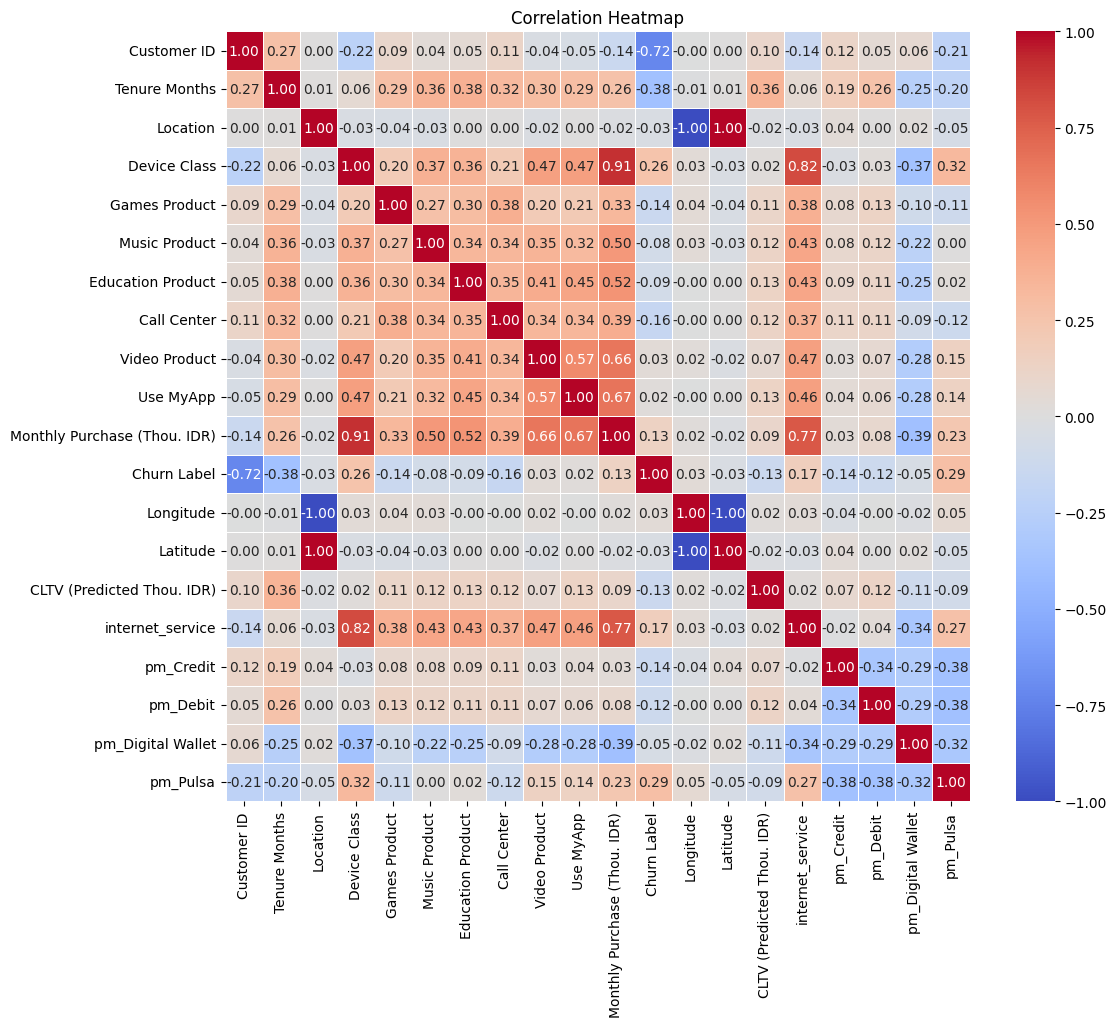

In [8]:
import matplotlib.pyplot as plt

# Assuming you have your dataset in a DataFrame called "df"
# If you don't have Seaborn data, you can use sns.heatmap(df.corr(), annot=True) for a basic heatmap
# Here, we will create a heatmap with custom labels for better readability

# Compute the correlation matrix
corr_matrix = data.corr()

# Create a figure and set its size
plt.figure(figsize=(12, 10))

# Create a heatmap with custom labels
sns.heatmap(
    corr_matrix,
    annot=True,  # Show correlation values in the cells
    cmap='coolwarm',  # Choose a color map
    linewidths=0.5,  # Add linewidth between cells for better readability
    fmt=".2f",  # Format correlation values to 2 decimal places
)

# Set the title
plt.title("Correlation Heatmap")

# Show the heatmap
plt.show()


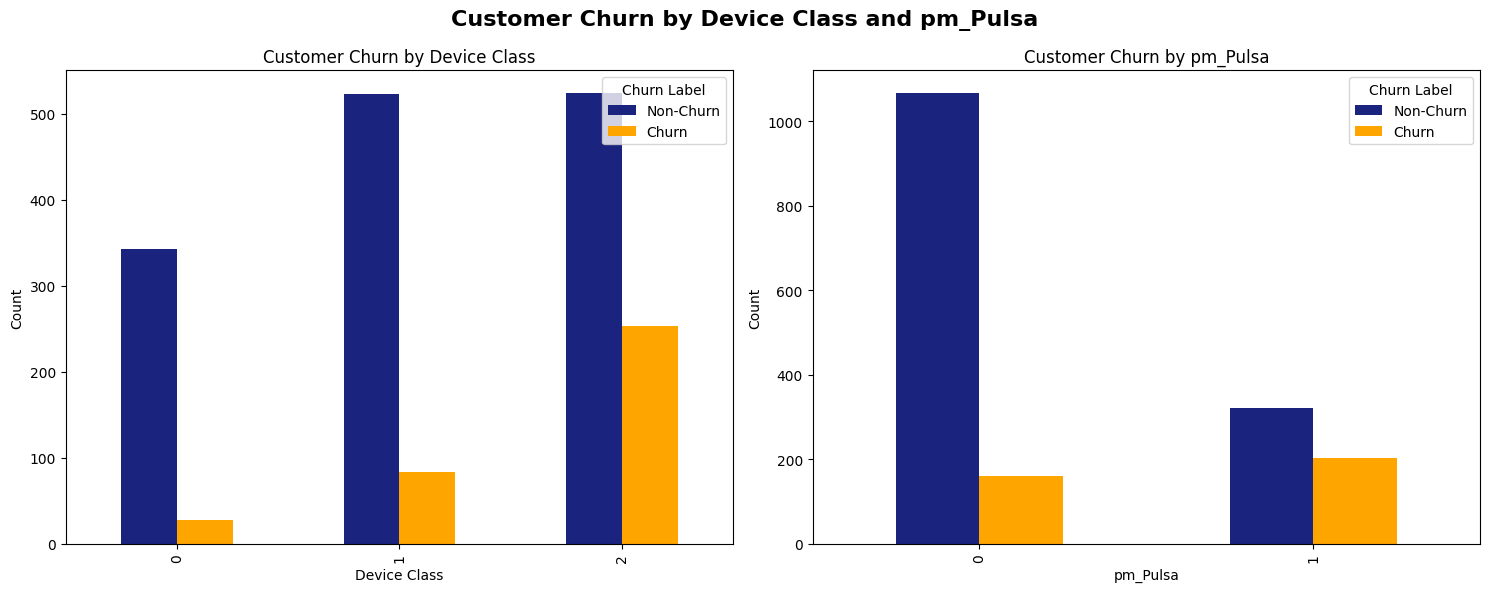

In [9]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15,6))

colors = ['#1a237e', '#FFA500'] 
device_class_churn_counts = data.groupby(['Device Class', 'Churn Label'])['Churn Label'].count().unstack().plot(ax=ax1, kind='bar', color=colors)
ax1.set_xlabel('Device Class')
ax1.set_ylabel('Count')
ax1.set_title('Customer Churn by Device Class')
ax1.legend(['Non-Churn', 'Churn'], title='Churn Label', loc='upper right')

pm_pulsa_churn_counts = data.groupby(['pm_Pulsa', 'Churn Label'])['Churn Label'].count().unstack().plot(ax=ax2, kind='bar', color=colors)
ax2.set_xlabel('pm_Pulsa')
ax2.set_ylabel('Count')
ax2.set_title('Customer Churn by pm_Pulsa')
ax2.legend(['Non-Churn', 'Churn'], title='Churn Label', loc='upper right')

plt.suptitle('Customer Churn by Device Class and pm_Pulsa', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
pd.crosstab(data['Churn Label'], data['Device Class'])

Device Class,0,1,2
Churn Label,,,
0,342,523,524
1,27,83,253


In [11]:
data.groupby('Device Class')['Churn Label'].mean()

Device Class
0    0.073171
1    0.136964
2    0.325611
Name: Churn Label, dtype: float64

In [12]:
data['Churn Label']

5       1
6       1
8       1
13      1
14      1
       ..
7018    0
7021    0
7026    0
7031    0
7040    0
Name: Churn Label, Length: 1752, dtype: int64

In [13]:
eda_features = data.drop(['Longitude', 'Latitude','Churn Label', 'Location'] ,axis=1)

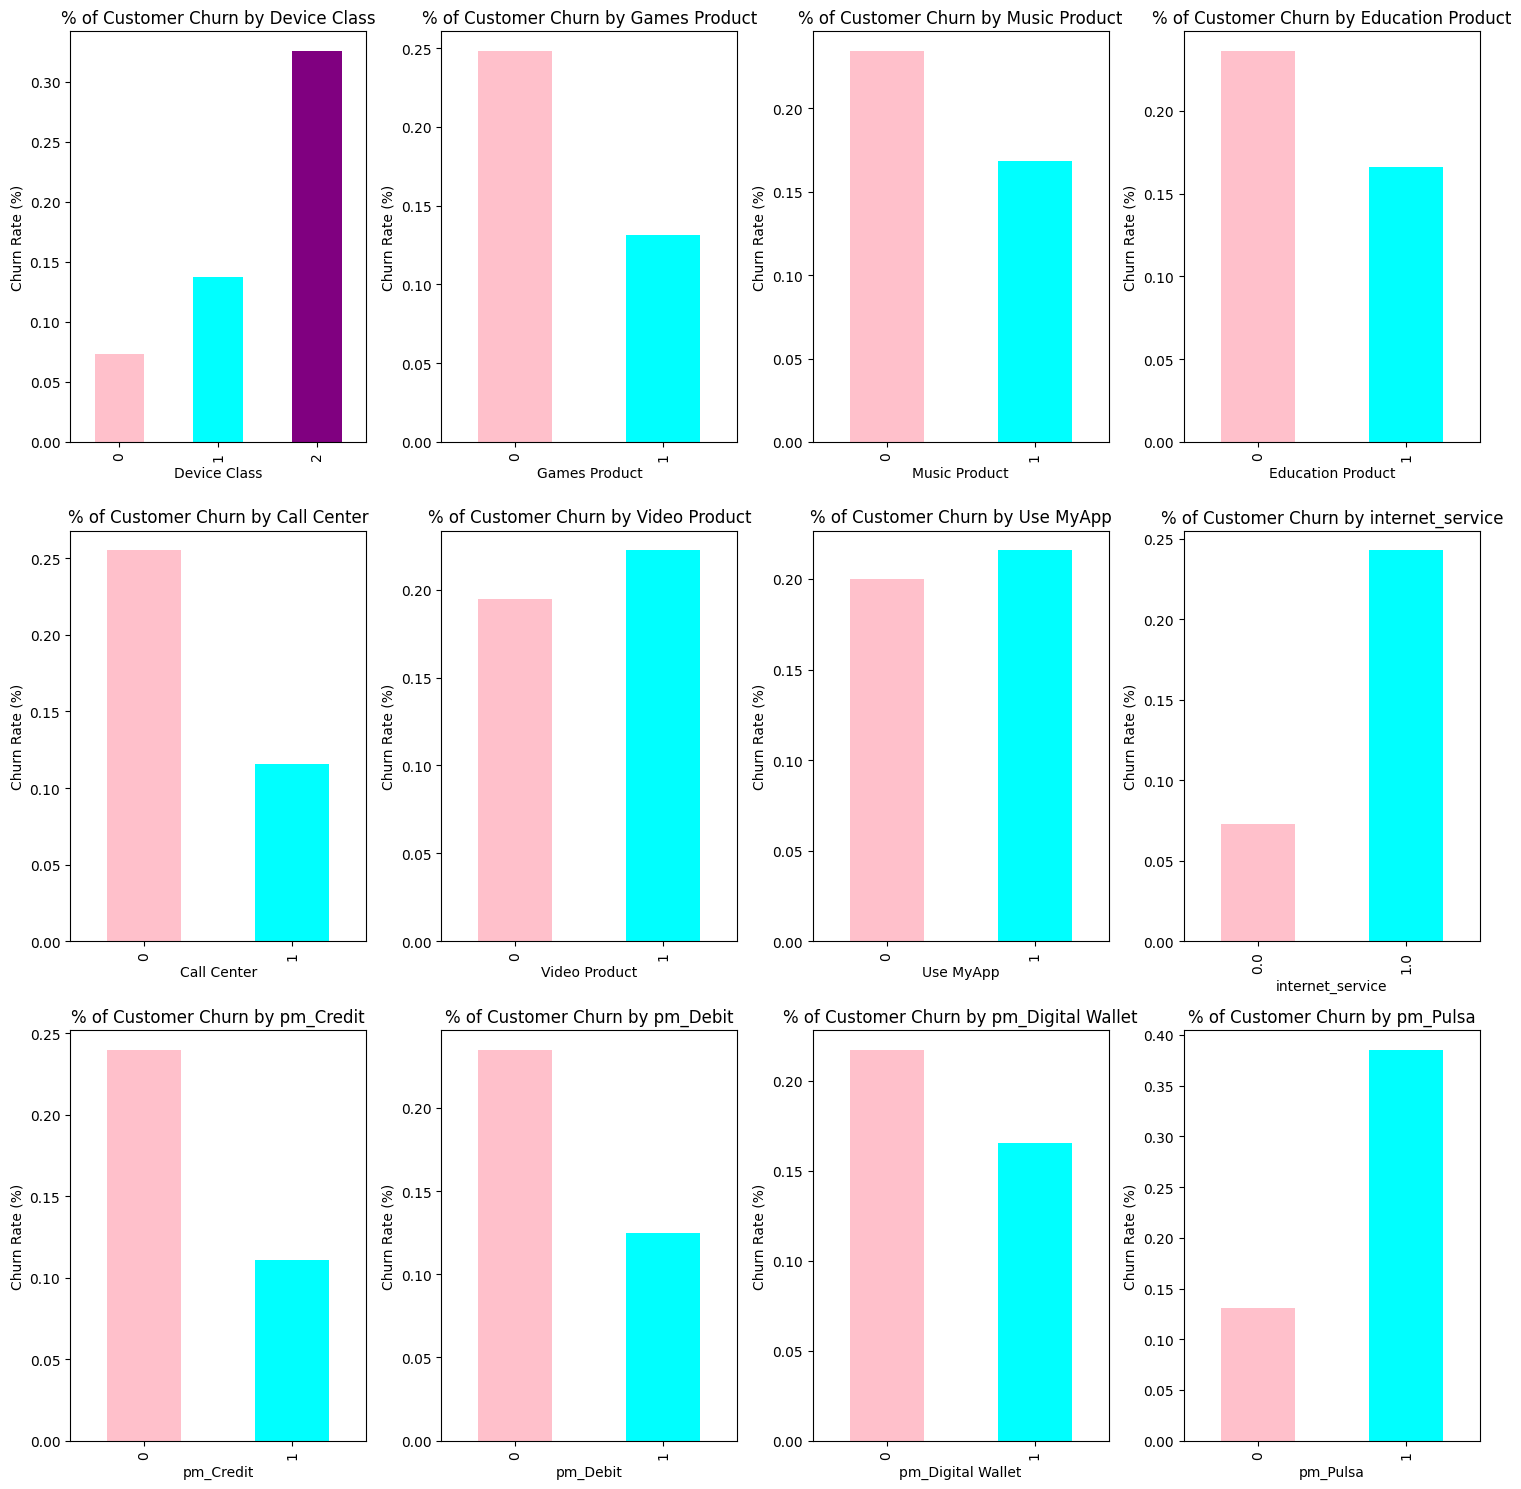

In [14]:
# Filter columns with 3 or fewer unique values
selected_columns = [col for col in eda_features.columns if eda_features[col].nunique() <= 3]

# Set colors for 'Yes' and 'No'
colors = { 1 : 'aqua', 0 : 'pink', 2 : 'purple'}

# Calculate the number of rows needed
num_rows = (len(selected_columns) + 3) // 4

# Create subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=4, figsize=(15, 5 * num_rows))

# Loop through selected columns and plot the mean tenure
for i, col in enumerate(selected_columns):
    row = i // 4
    col_num = i % 4
    group_churn_rate = data.groupby(col)['Churn Label'].mean()
    group_churn_rate.plot(kind='bar', stacked=True, color=[colors.get(label, 'gray') for label in group_churn_rate.index], ax=axes[row, col_num])
    axes[row, col_num].set_xlabel(col)
    axes[row, col_num].set_ylabel('Churn Rate (%)')
    axes[row, col_num].set_title(f'% of Customer Churn by {col}')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


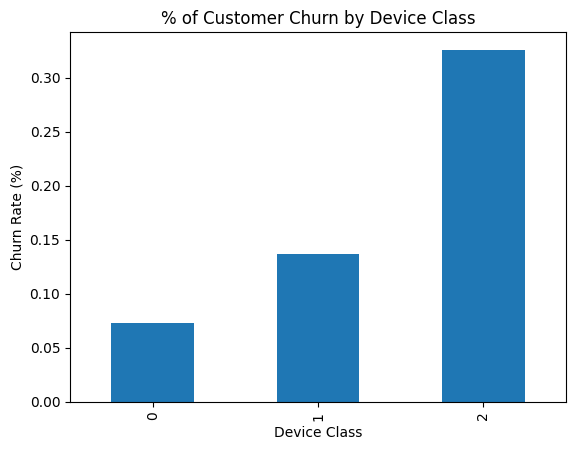

In [15]:
# assuming customer_tr is your DataFrame containing relevant data
device_class_churn_rate = data.groupby('Device Class')['Churn Label'].mean()

# plot the mean tenure by internet service and churn value
device_class_churn_rate.plot(kind='bar', stacked=True)
plt.xlabel('Device Class')
plt.ylabel('Churn Rate (%)')
plt.title('% of Customer Churn by Device Class')
plt.show()

In [16]:
def Generate_heatmap_graph(corr, chart_title, mask_uppertri=False ):
    """ Based on features , generate correlation matrix """
    mask = np.zeros_like(corr)
    mask[np.triu_indices_from(mask)] = mask_uppertri

    fig,ax = plt.subplots(figsize=(12,12))
    sns.heatmap(corr
                , mask = mask
                , square = True
                , annot = True
                , annot_kws={'size': 8, 'weight' : 'bold'}
                , cmap=plt.get_cmap("YlOrBr")
                , linewidths=.1)
    plt.title(chart_title, fontsize=14)
    plt.show()

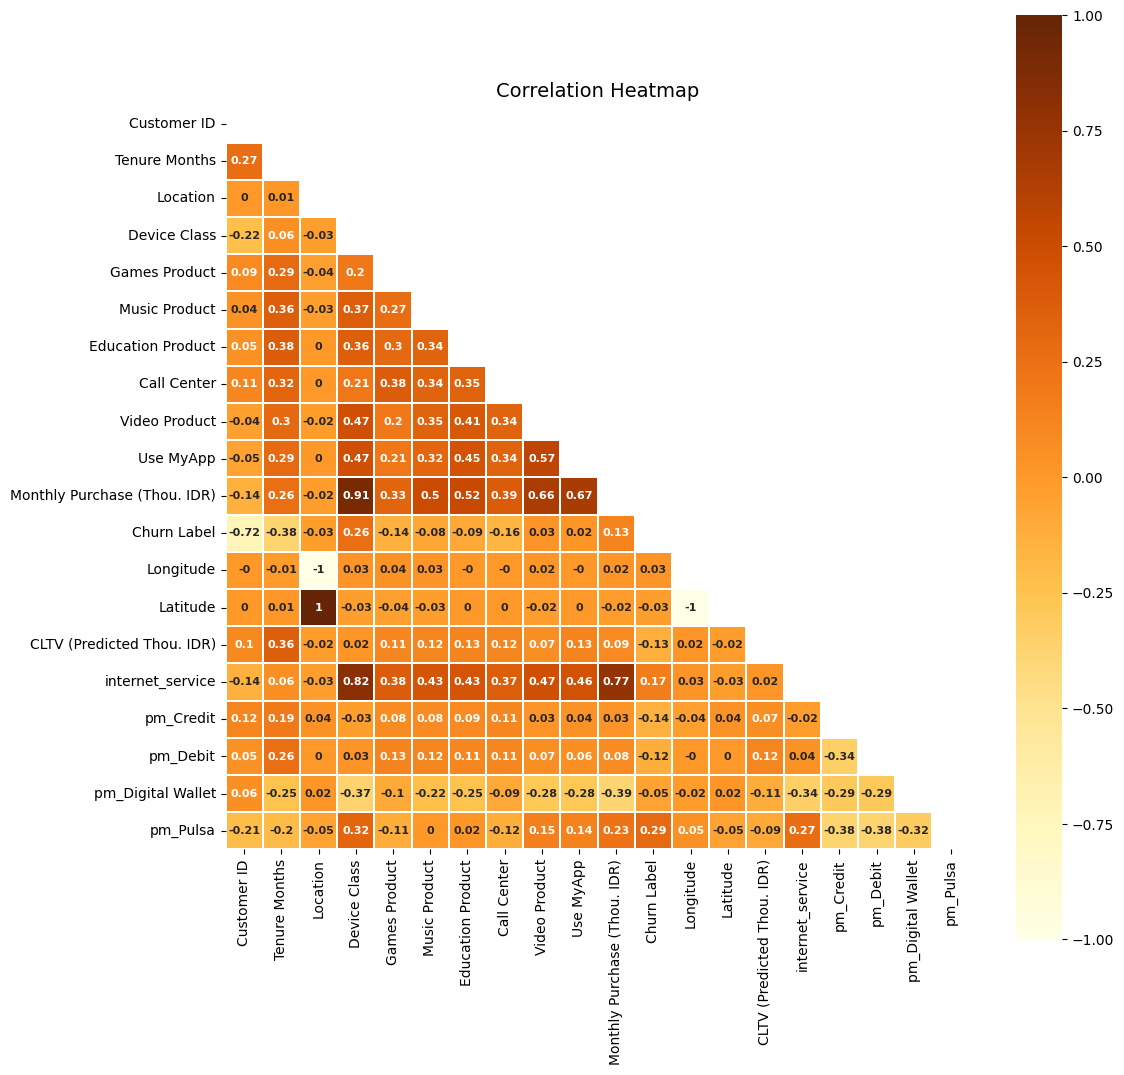

In [17]:
var_corr = round(data.corr(),2)
Generate_heatmap_graph(var_corr
                       ,chart_title = 'Correlation Heatmap'
                       ,mask_uppertri = True)

In [18]:
# X = data.drop(["Customer ID", "Churn Label",'Location','Longitude', 'Latitude'], axis=1)
X = data.drop(["Customer ID", "Churn Label"], axis=1)
y = data['Churn Label']

In [19]:
X

,Tenure Months,Location,Device Class,Games Product,Music Product,Education Product,Call Center,Video Product,Use MyApp,Monthly Purchase (Thou. IDR),Longitude,Latitude,CLTV (Predicted Thou. IDR),internet_service,pm_Credit,pm_Debit,pm_Digital Wallet,pm_Pulsa
5,10,1,1,0,0,1,1,0,0,71.760,106.816666,-6.2,7702.5,1.0,1,0,0,0
6,1,1,1,0,0,1,0,0,1,51.545,106.816666,-6.2,7062.9,1.0,0,0,0,1
8,47,1,2,0,1,0,0,1,1,129.155,106.816666,-6.2,7525.7,1.0,0,0,0,1
13,11,1,2,0,0,1,0,1,1,127.205,106.816666,-6.2,7376.2,1.0,0,1,0,0
14,2,1,2,0,0,0,0,1,0,104.845,106.816666,-6.2,7261.8,1.0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7018,62,1,1,1,1,0,1,1,1,110.435,106.816666,-6.2,8199.1,1.0,0,0,0,1
7021,34,1,2,0,0,1,0,1,0,110.760,106.816666,-6.2,7010.9,1.0,1,0,0,0
7026,72,1,2,0,1,1,0,1,1,136.435,106.816666,-6.2,7488.0,1.0,0,0,0,1
7031,68,1,1,0,1,0,1,1,0,83.330,106.816666,-6.2,7218.9,1.0,0,1,0,0


In [20]:
data[data['Customer ID'] > 3000]['Churn Label'].value_counts()

0    1079
Name: Churn Label, dtype: int64

In [22]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((1401, 18), (351, 18), (1401,), (351,))

In [23]:
import catboost
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, balanced_accuracy_score
catboost_model = CatBoostClassifier(verbose=0)
catboost_model.fit(X_train, y_train)
val_pred = catboost_model.predict(X_val)
score = balanced_accuracy_score(y_val, val_pred)
score_2 = f1_score(y_val, val_pred, average='macro')
print('acc:', score)
print('f1', score_2)

acc: 0.6356065832265694
f1 0.6572111122797002


In [24]:
# Split the data into initial labeled set and unlabeled pool by class
X_class1, X_class0, y_class1, y_class0 = X_train[y_train == 1], X_train[y_train == 0], y_train[y_train == 1], y_train[y_train == 0]

# Create an initial labeled pool with a mix of class 1 and some class 0 instances
X_labeled_class1, y_labeled_class1 = X_class1, y_class1
X_labeled_class0, y_labeled_class0 = X_class0[:10], y_class0[:10]

X_labeled = pd.concat([X_labeled_class1, X_labeled_class0])
y_labeled = np.hstack([y_labeled_class1, y_labeled_class0])

# Create an initial unlabeled pool with the remaining instances of class 0
X_unlabeled, y_unlabeled = X_class0[10:], y_class0[10:]

n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
f1_scorer = make_scorer(f1_score)
mean_f1_score = 0

best_model = None
best_f1_macro = 0

while len(X_unlabeled) > 0:
    # Train a CatBoost classifier on the current labeled set
    catboost_model = CatBoostClassifier(verbose=0)
    catboost_model.fit(X_labeled, y_labeled)

    # Use the trained classifier to make predictions on the unlabeled pool
    predicted_probs = catboost_model.predict_proba(X_unlabeled)[:, 1]

    # Select the most informative data points from the unlabeled pool
    informative_indices = np.argsort(np.abs(predicted_probs - 0.5))
    selected_indices = informative_indices[:min(50, len(informative_indices))]  # Select top 10 informative samples

    # Update the labeled set with the selected informative data points
    X_labeled = X_labeled.append(X_unlabeled.iloc[selected_indices])
    y_labeled = np.hstack((y_labeled, y_unlabeled.iloc[selected_indices]))

    # Remove the selected samples from the unlabeled pool
    X_unlabeled = X_unlabeled.drop(X_unlabeled.index[selected_indices])
    y_unlabeled = y_unlabeled.drop(y_unlabeled.index[selected_indices])

    # Evaluate the model on the current labeled set using cross-validation
    val_pred = catboost_model.predict(X_val)

    score = f1_score(y_val, val_pred, average="macro")
    if score > best_f1_macro:
        best_f1_macro = score
        best_model = catboost_model
    print("Macro F1-Score: ", score)
    f1 = f1_score(y_val, val_pred)

    score = balanced_accuracy_score(y_val, val_pred)
    print('acc:', score)

    print(f"Mean F1 Score after {len(X_labeled)} labeled samples: {f1}")
    print(classification_report(y_val,val_pred))

# Save the best model to a pickle file
import pickle

print(best_f1_macro)
with open('best_model.pkl', 'wb') as model_file:
    pickle.dump(best_model, model_file)

# The loop continues until there are no more informative data points in the pool


Macro F1-Score:  0.21481773167891285
acc: 0.5197841726618705
Mean F1 Score after 350 labeled samples: 0.35351089588377727
              precision    recall  f1-score   support

           0       1.00      0.04      0.08       278
           1       0.21      1.00      0.35        73

    accuracy                           0.24       351
   macro avg       0.61      0.52      0.21       351
weighted avg       0.84      0.24      0.13       351

Macro F1-Score:  0.32875122589081396
acc: 0.579136690647482
Mean F1 Score after 400 labeled samples: 0.38421052631578945
              precision    recall  f1-score   support

           0       1.00      0.16      0.27       278
           1       0.24      1.00      0.38        73

    accuracy                           0.33       351
   macro avg       0.62      0.58      0.33       351
weighted avg       0.84      0.33      0.30       351

Macro F1-Score:  0.3929850200949945
acc: 0.6118557209027299
Mean F1 Score after 450 labeled samples: 0.

### Oversampling: SMOTE

In [25]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the training data
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Create a CatBoostClassifier
catboost_model = CatBoostClassifier(verbose=0)

# Fit the model on the resampled data
catboost_model.fit(X_train_resampled, y_train_resampled)

# Predict on the validation set
val_pred = catboost_model.predict(X_val)

# Evaluate the model
score = balanced_accuracy_score(y_val, val_pred)
score_2 = f1_score(y_val, val_pred, average='macro')

print('Balanced Accuracy:', score)
print('F1 Score (macro):', score_2)

Balanced Accuracy: 0.668818369961565
F1 Score (macro): 0.6799688148314547


### Oversampling: ADASYN

In [26]:
from imblearn.over_sampling import ADASYN

# Apply ADASYN to the training data
adasyn = ADASYN(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = adasyn.fit_resample(X_train, y_train)

# Create a CatBoostClassifier
catboost_model = CatBoostClassifier(verbose=0)

# Fit the model on the resampled data
catboost_model.fit(X_train_resampled, y_train_resampled)

# Predict on the validation set
val_pred = catboost_model.predict(X_val)

# Evaluate the model
score = balanced_accuracy_score(y_val, val_pred)
score_2 = f1_score(y_val, val_pred, average='macro')

print('Balanced Accuracy:', score)
print('F1 Score (macro):', score_2)

Balanced Accuracy: 0.7012663841529516
F1 Score (macro): 0.7084605849955915


### Undersampling: Random Undersampling

In [27]:
from imblearn.under_sampling import RandomUnderSampler

# Apply RandomUnderSampler to the training data
rus = RandomUnderSampler(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

# Create a CatBoostClassifier
catboost_model = CatBoostClassifier(verbose=0)

# Fit the model on the resampled data
catboost_model.fit(X_train_resampled, y_train_resampled)

# Predict on the validation set
val_pred = catboost_model.predict(X_val)

# Evaluate the model
score = balanced_accuracy_score(y_val, val_pred)
score_2 = f1_score(y_val, val_pred, average='macro')

print('Balanced Accuracy:', score)
print('F1 Score (macro):', score_2)

Balanced Accuracy: 0.73171873460136
F1 Score (macro): 0.6738863302596481


### Undersampling: NearMiss

In [28]:
from imblearn.under_sampling import NearMiss

# Apply NearMiss to the training data
nm = NearMiss(sampling_strategy='auto', version=2)
X_train_resampled, y_train_resampled = nm.fit_resample(X_train, y_train)

# Create a CatBoostClassifier
catboost_model = CatBoostClassifier(verbose=0)

# Fit the model on the resampled data
catboost_model.fit(X_train_resampled, y_train_resampled)

# Predict on the validation set
val_pred = catboost_model.predict(X_val)

# Evaluate the model
score = balanced_accuracy_score(y_val, val_pred)
score_2 = f1_score(y_val, val_pred, average='macro')

print('Balanced Accuracy:', score)
print('F1 Score (macro):', score_2)

Balanced Accuracy: 0.5711047600275944
F1 Score (macro): 0.3844904851594466
